In [1]:
import pandas as pd
import numpy as np
# Plotting to understand data trends
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv('../data/raw/online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
nulls = df.isnull().sum()
null_percent = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values": nulls,
    "Percentage": null_percent
})

missing_df

,Missing Values,Percentage
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,1454,0.268311
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,135080,24.926694
Country,0,0.000000


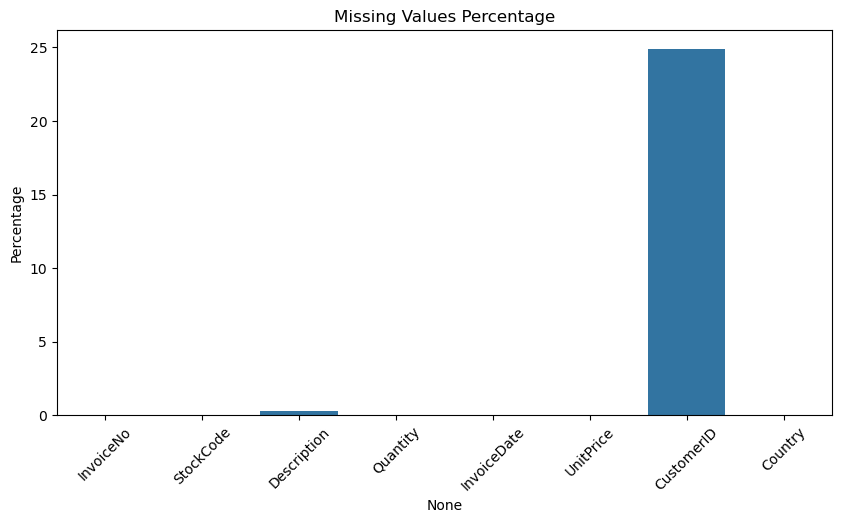

In [6]:
plt.figure(figsize=(10,5))
sns.barplot(x=missing_df.index, y=missing_df["Percentage"])
plt.xticks(rotation=45)
plt.title("Missing Values Percentage")
plt.show()

In [7]:
df = df.dropna(subset=['CustomerID'])
df = df.dropna(subset=['Description'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df.shape

(397884, 8)

In [8]:
# Convert InvoiceDate to datetime and CustomerID to integer
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

## Feature Engineering

In [9]:
# Calculate total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [10]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

## Plotting to get Visual Info about Data

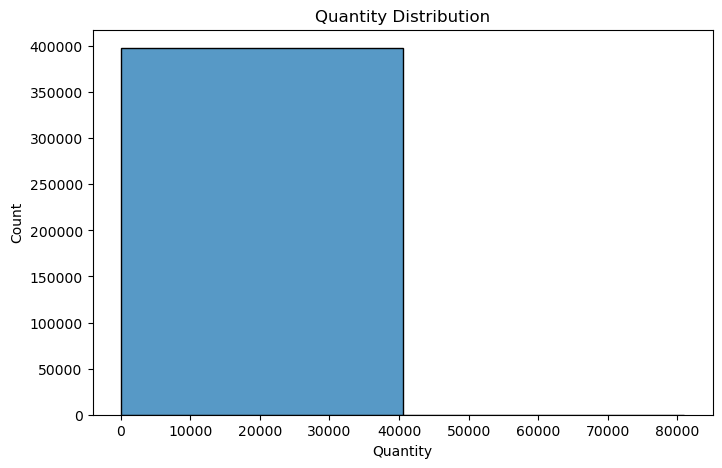

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=2)
plt.title("Quantity Distribution")
plt.show()

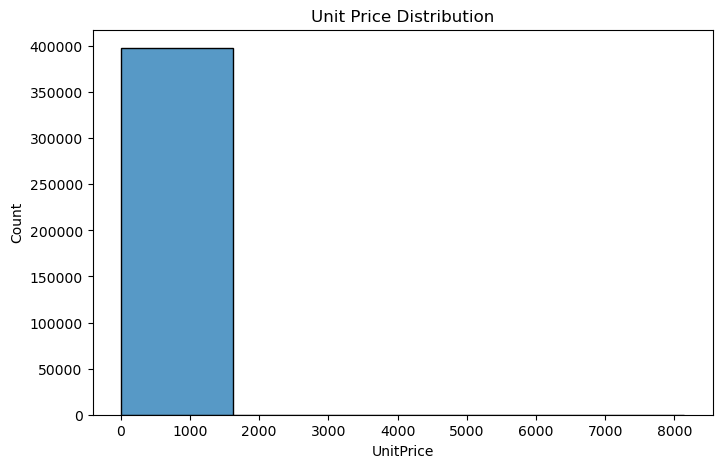

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['UnitPrice'], bins=5)
plt.title("Unit Price Distribution")
plt.show()

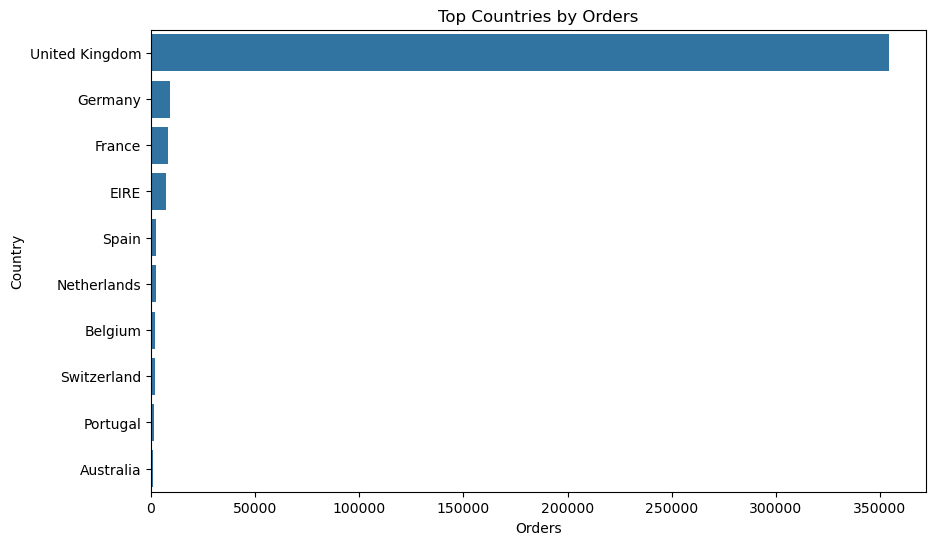

In [13]:
top_countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top Countries by Orders")
plt.xlabel("Orders")
plt.show()

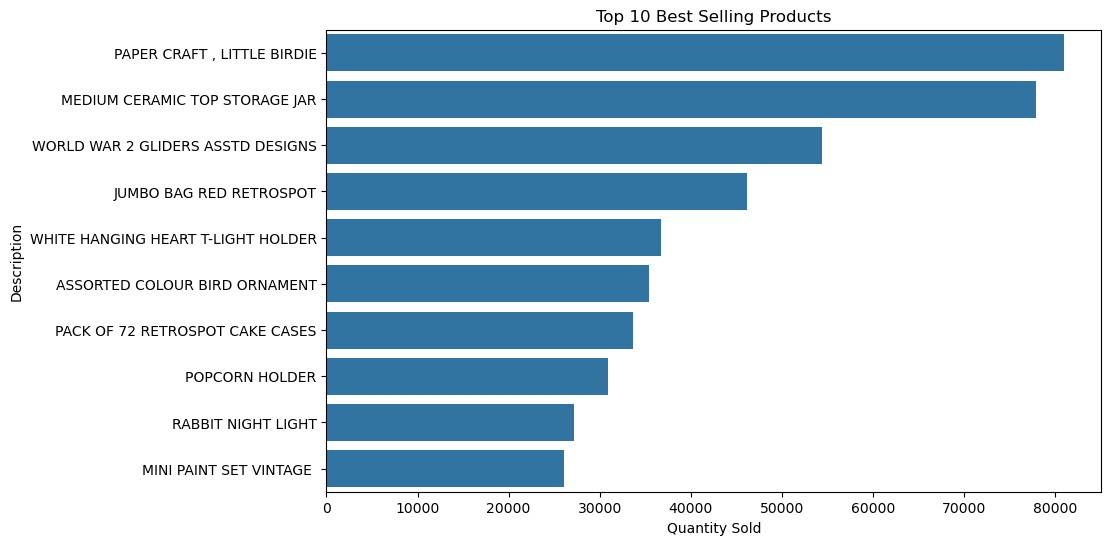

In [14]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Best Selling Products")
plt.xlabel("Quantity Sold")
plt.show()

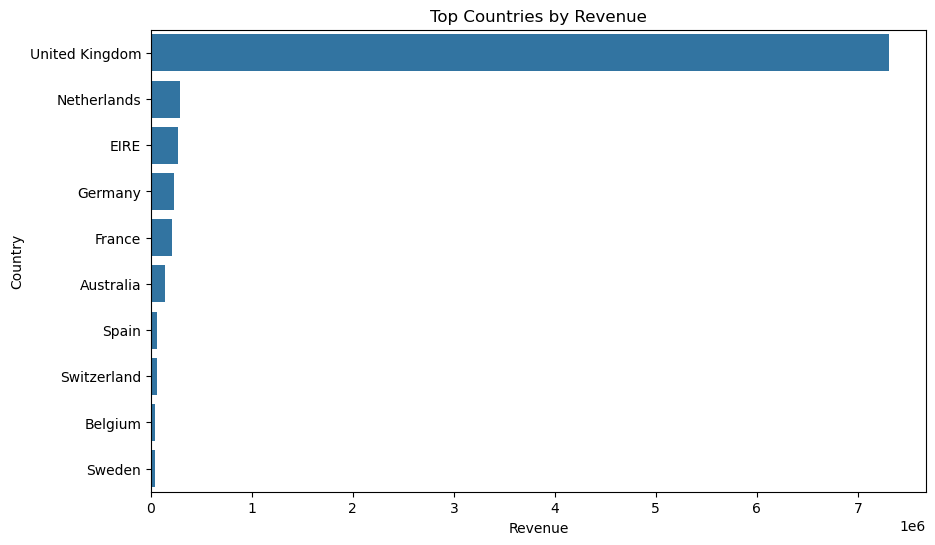

In [15]:
revenue_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=revenue_country.values, y=revenue_country.index)
plt.title("Top Countries by Revenue")
plt.xlabel("Revenue")
plt.show()

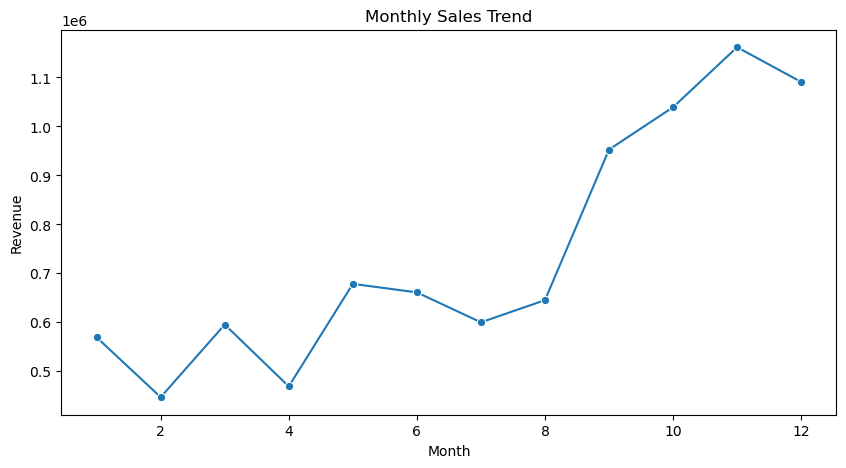

In [16]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

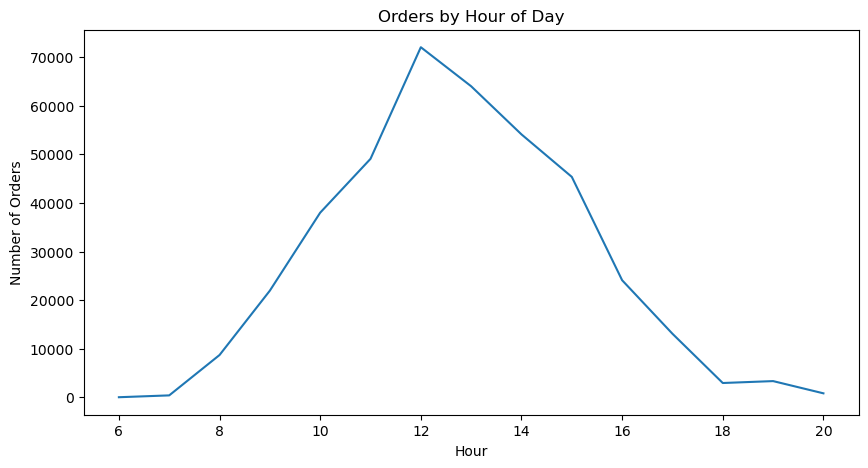

In [17]:
hourly_sales = df.groupby('Hour')['InvoiceNo'].count()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values)
plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.show()

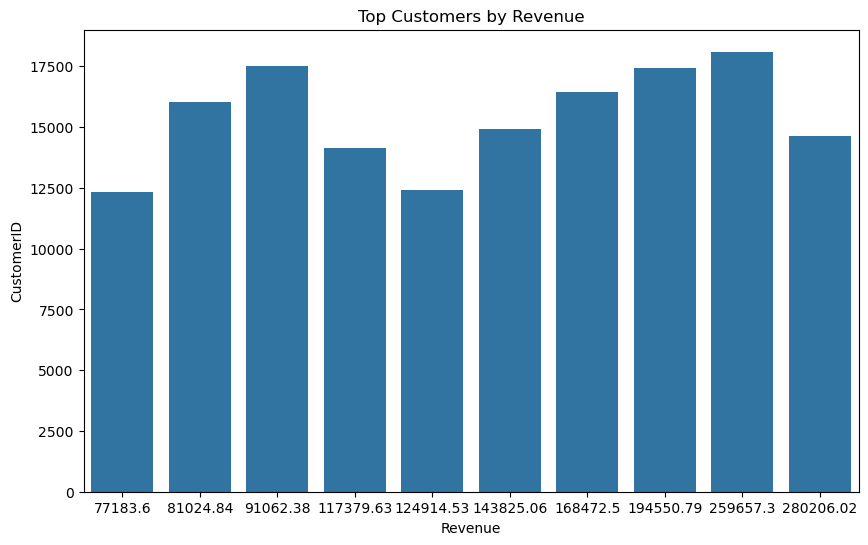

In [18]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top Customers by Revenue")
plt.xlabel("Revenue")
plt.show()

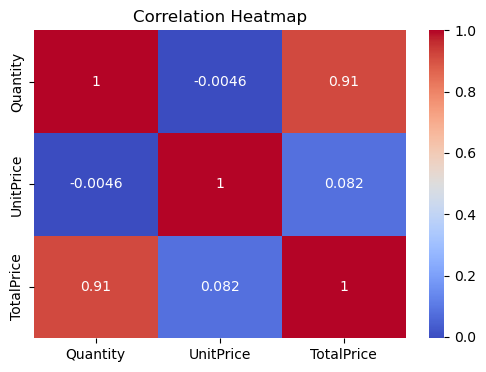

In [19]:
numeric_df = df[['Quantity','UnitPrice','TotalPrice']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

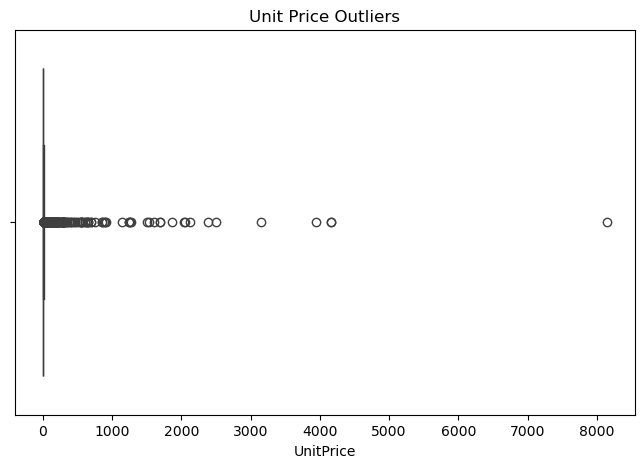

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['UnitPrice'])
plt.title("Unit Price Outliers")
plt.show()

In [21]:
print("Unique Products:", df['StockCode'].nunique())
print("Unique Customers:", df['CustomerID'].nunique())
print("Countries:", df['Country'].nunique())

Unique Products: 3665
Unique Customers: 4338
Countries: 37


In [30]:
# Adding Additional Features to the Dataset
df['is_weekend'] = df['InvoiceDate'].dt.weekday >= 5
df['is_night'] = (df['Hour'] >= 21) | (df['Hour'] <= 6)

In [31]:
avg_purchase_value = df.groupby('CustomerID').agg(
    total_spent=('TotalPrice','sum'),
    total_orders=('InvoiceNo','nunique')
)

avg_purchase_value['avg_purchase_value'] = (
    avg_purchase_value['total_spent'] /
    avg_purchase_value['total_orders']
)

avg_purchase_value = avg_purchase_value[['avg_purchase_value']]

In [32]:
purchase_frequency = df.groupby('CustomerID').agg(
    purchase_frequency=('InvoiceNo','nunique')
)

In [33]:
unique_products = df.groupby('CustomerID').agg(
    unique_products_bought=('StockCode','nunique')
)

In [34]:
df_sorted = df.sort_values(['CustomerID','InvoiceDate'])

time_diff = df_sorted.groupby('CustomerID')['InvoiceDate'].diff()

avg_time_between = time_diff.groupby(df_sorted['CustomerID']).mean()

avg_time_between = avg_time_between.dt.days

avg_time_between = avg_time_between.to_frame(
    name='avg_time_between_purchases'
)

In [35]:
weekend_ratio = df.groupby('CustomerID').agg(
    weekend_purchase_ratio=('is_weekend','mean')
)

In [36]:
night_ratio = df.groupby('CustomerID').agg(
    night_purchase_ratio=('is_night','mean')
)

In [37]:
country_diversity = df.groupby('CustomerID').agg(
    country_diversity=('Country','nunique')
)

In [39]:
customer_features = (
    avg_purchase_value
    .join(purchase_frequency)
    .join(unique_products)
    .join(avg_time_between)
    .join(weekend_ratio)
    .join(night_ratio)
    .join(country_diversity)
)

customer_features.head()

,avg_purchase_value,purchase_frequency,unique_products_bought,avg_time_between_purchases,weekend_purchase_ratio,night_purchase_ratio,country_diversity
CustomerID,,,,,,,
12346,77183.600000,1,1,NaN,0.000000,0.0,1
12347,615.714286,7,103,2.0,0.000000,0.0,1
12348,449.310000,4,22,9.0,0.096774,0.0,1
12349,1757.550000,1,73,0.0,0.000000,0.0,1
12350,334.400000,1,17,0.0,0.000000,0.0,1


In [40]:
df = df.merge(customer_features, on='CustomerID', how='left')

In [43]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month',
       'Day', 'Hour', 'is_weekend', 'is_night', 'avg_purchase_value',
       'purchase_frequency', 'unique_products_bought',
       'avg_time_between_purchases', 'weekend_purchase_ratio',
       'night_purchase_ratio', 'country_diversity'],
      dtype='object')

In [44]:
df.to_csv('../data/processed/online_retail_processed.csv', index=False)